# 캡스톤: 호주 항당뇨제 처방 건수 예측

목표: 1991년부터 2008년까지의 호주 항당뇨제 처방 건수를 예측. 실제 사업에서 이 문제를 해결할 수 있다면 항당뇨제의 생산량을 측정해 수요를 충족하면서도 과잉 생산을 피할 수 있음. 

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/AusAntidiabeticDrug.csv')
df
#204 rows
#y = 월별 처방 건수

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869
...,...,...
199,2008-02-01,21.654285
200,2008-03-01,18.264945
201,2008-04-01,23.107677
202,2008-05-01,22.912510


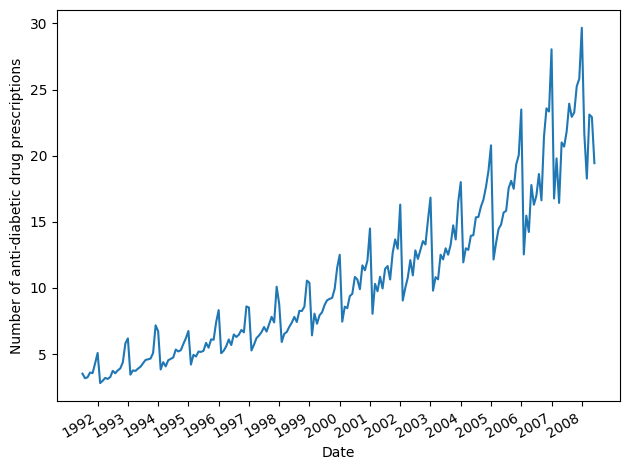

In [ ]:
fig, ax = plt.subplots()

ax.plot(df.y)
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
#데이터의 row index 6가 1992년의 시작; 203이 마지막;
# 1년은 12개월이므로 12칸 간격으로 선 내놓기

fig.autofmt_xdate()
plt.tight_layout()


도식
- 추세 Trend: 시간의 흐름에 따라 처방 건수가 증가
- 계절성 Seasonality: 매년 낮은 값에서 시작하고 높은 값에서 끝나는 강한 계절성

**어떤 모델이 이 문제를 해결하는 데 가장 적합한지 직관적으로 알 수 있음**

거쳐야 하는 단계:
1) 목표: 12개월 동안의 항당뇨제 처방 건수를 예측. 롤링 예측을 수행할 수 있도록 데이터 집합에서 지난 36개월을 테스트 집합으로 사용.
2) 시계열 시각화.
3) 시계열 분해를 사용해 추세 및 계절적 구성요소를 추출.
4) 탐색을 기반으로 가장 적합한 모델을 결정.
5) 일반적인 단계에 따라 시계열 모델링
    a) 변환을 통해 시계열을 정상적으로
    b) d와 D 값 설정 &  m 값 설정
    c) 최적의 (p,d,q)(P,D,Q)$_m$ 매개변수 탐색
    d) 잔차 분석을 수행해 모델 검증
6) 테스트 집합에 대해 12개월의 롤릴 예측 수행.
7) 예측을 시각화.
8) 모델의 성능을 베이스라인 모델과 비교. 적절한 베이스라인 모델과 오차 지표 선택.
9) 모델을 사용해야 할지에 대해 결론을 내림.



# 시계열 분해 작업

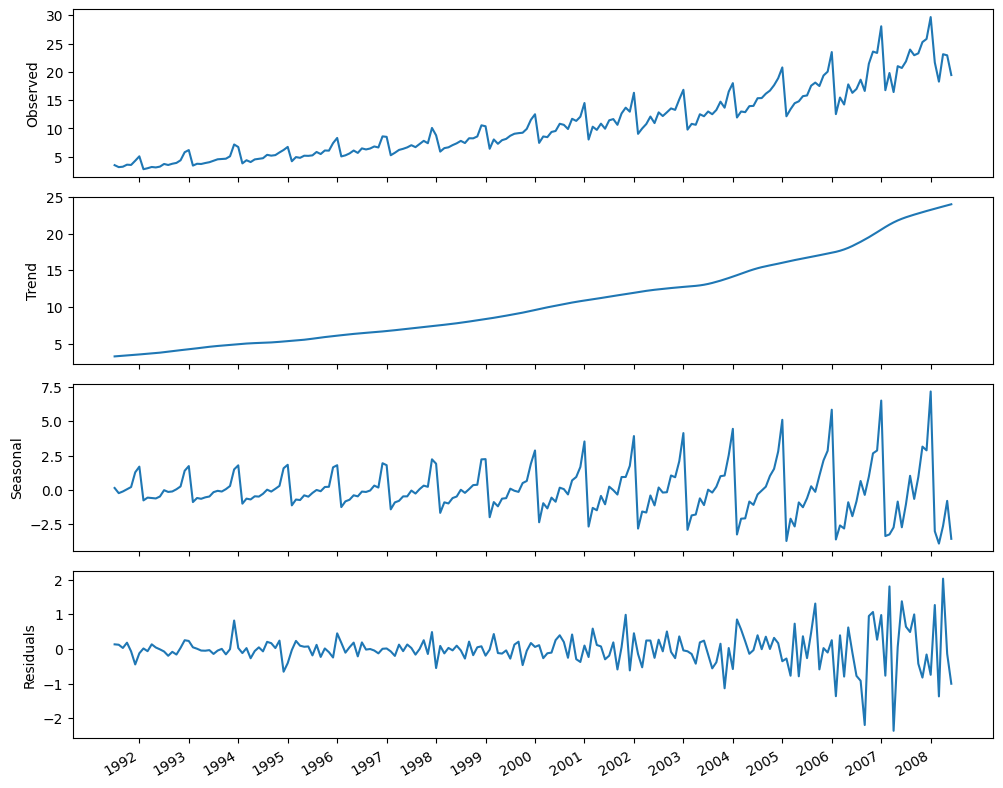

In [6]:
decomp = STL(df.y, period = 12).fit() 
#월별 데이터이니 period = 12

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 4, ncols = 1,
                                         sharex = True, figsize = (10,8))

ax1.plot(decomp.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomp.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomp.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomp.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()

추세가 있고 계절성이 있음
- SARIMAX(p,d,q)(P,D,Q)$_m$ 최적 모델
- 외생변수는 없으니 SARIMAX 불가.
- 하나의 대상만 예측하고자 하니 VAR 모델도 불가. 

# 정상성 확인

In [7]:
ad_fuller_result = adfuller(df.y)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'ADF P-val: {ad_fuller_result[1]}')

ADF Stats: 3.145185689306745
ADF P-val: 1.0


In [8]:
y_diff = np.diff(df.y, n=1)

ad_fuller_result = adfuller(y_diff)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'ADF P-val: {ad_fuller_result[1]}')

ADF Stats: -2.495172147449745
ADF P-val: 0.1166534168646865


In [9]:
# 데이터에서 강한 계절적 패턴이 있으므로 계절적 차분 적용.
# 월별 데이터이므로 m = 12

y_diff_seasonal_diff = np.diff(y_diff, n = 12)

ad_fuller_result = adfuller(y_diff_seasonal_diff)

print(f'ADF Stats: {ad_fuller_result[0]}')
print(f'ADF P-val: {ad_fuller_result[1]}')

ADF Stats: -19.848440099535072
ADF P-val: 0.0


주의: 
- 첫번째 차분은 시계열 자체에 대한 차분 --> d = 1
- 두번째 차분은 계절적 차분 --> D = 1 (m = 12)

최종 모델:  
SARIMAX(p,1,q)(P,1,Q)$_{12}$

# AIC 최소화하는 p,q,P,Q 찾기

In [ ]:
# train, test division

train = df.y[:168]
test = df.y[168:]

print(len(test)) 
#output: 36 months

36


In [16]:
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], 
                     order_list: list, d: int, D: int, s: int) -> pd.DataFrame: #여기서 s는 SARIMAX(p,d,q)(P,D,Q)_m의 m을 지칭

    results = []

    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog, exog, order = (order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except: 
            continue

        aic = model.aic
        results.append([order, model.aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']

    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True)

    return result_df

In [15]:
ps = range(0, 5, 1)
qs = range(0, 5, 1)
Ps = range(0, 5, 1)
Qs = range(0, 5, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 1
s = 12

In [17]:
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s)
#왜 exog 자리에 None? --> 여기서는 외생변수가 없음
SARIMA_result_df

  0%|          | 0/625 [00:00<?, ?it/s]

,"(p,q,P,Q)",AIC
0,"(3, 1, 1, 3)",270.951096
1,"(2, 4, 1, 3)",271.217323
2,"(3, 3, 1, 3)",271.470623
3,"(4, 1, 1, 3)",272.145293
4,"(0, 4, 1, 3)",272.152380
...,...,...
619,"(0, 0, 0, 4)",351.680917
620,"(0, 0, 2, 4)",353.644409
621,"(0, 0, 0, 1)",354.751719
622,"(0, 0, 1, 0)",357.173706


결과:
- SARIMA(3,1,1)(1,1,3)
- 위에서 언급했듯이, 외생 변수가 없기에 SARIMAX가 아닌 SARIMA로 진행.

# 잔차 분석

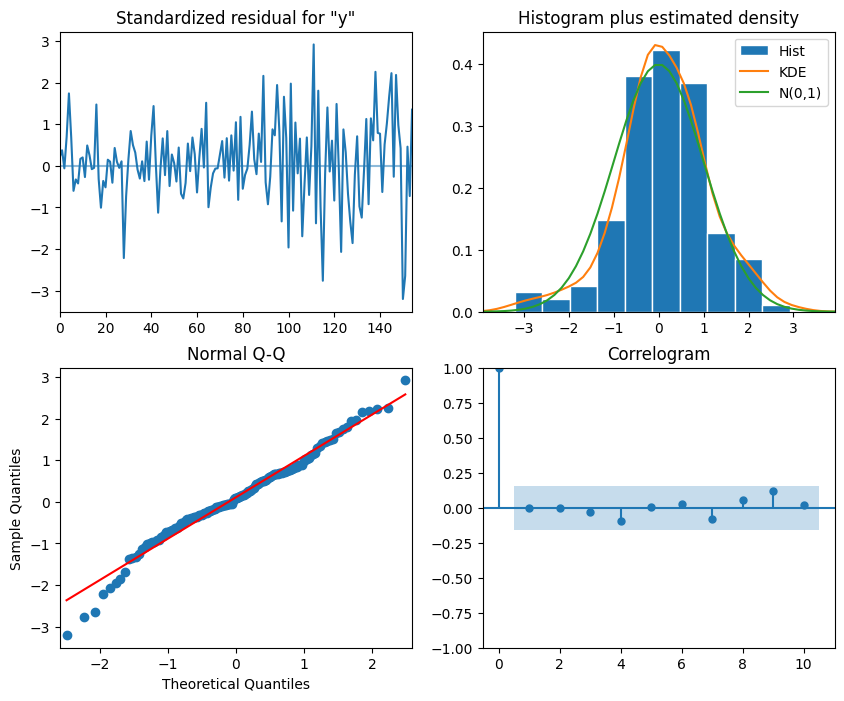

In [20]:
SARIMA_model = SARIMAX(train, order = (3,1,1), seasonal_order=(1,1,3, 12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp = False)

SARIMA_model_fit.plot_diagnostics(figsize = (10,8));

In [21]:
#Ljung Box Test

residuals = SARIMA_model_fit.resid 
ljung_result = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(ljung_result)

      lb_stat  lb_pvalue
1    0.436815   0.508664
2    0.627558   0.730681
3    0.646081   0.885807
4    2.258463   0.688341
5    2.950648   0.707594
6    3.389606   0.758595
7    9.982362   0.189575
8   10.592292   0.225887
9   11.854288   0.221649
10  11.985621   0.286020


모든 p-값들이 0.05 이상이기 때문에 귀무가설을 기각하지 않으며 잔차가 독립적이고 상관관계가 없다는 결론을 내릴 수 있음.

# 예측 수행, 모델 성능 평가 / 비교

In [25]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int,
                     window: int, method: str) -> list:
    #window: 한 번에 몇 스텝씩 예측/갱신 할것인가
    #horizon: 전체 예측 기간
    total_len = train_len + horizon
    end_idx = train_len

    if method == 'last_season':
        pred_last_season = []

        for i in range(train_len, total_len, window):
            last_season = df['y'][i - window: i].values
            pred_last_season.extend(last_season)

        return pred_last_season

    elif method == 'SARIMA':
        pred_SARIMA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df['y'][:i], order = (3,1,1), seasonal_order=(1,1,3,12), simple_differencing=False)
            res = model.fit(disp = False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)

        return pred_SARIMA

In [23]:
pred_df = df[168:]

In [26]:
# df에는 204개의 row; test에는 36개의 요소 --> train: 204-36 = 168
# test: 36 months 
# 한 번에 12개월을 예측하므로 window = 12

TRAIN_LEN = 168
HORIZON = 36
WINDOW = 12

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

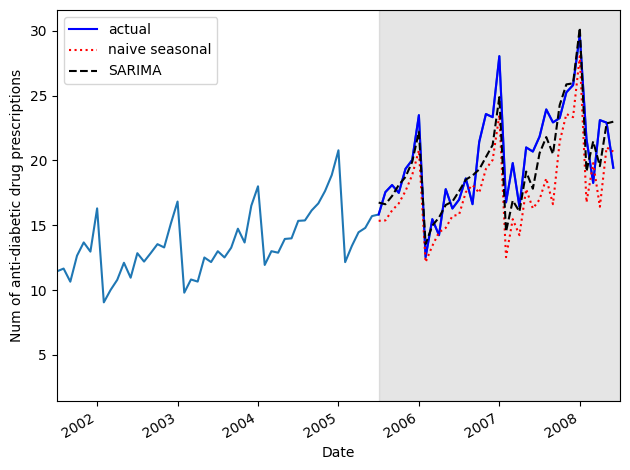

In [27]:
fig, ax = plt.subplots()

ax.plot(df.y)
ax.plot(pred_df.y, 'b-', label = 'actual')
ax.plot(pred_df.last_season, 'r:', label = 'naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label = 'SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Num of anti-diabetic drug prescriptions')
ax.axvspan(168, 204, color = '#808080', alpha = 0.2)

ax.legend(loc = 2)

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
plt.xlim(120, 204)

fig.autofmt_xdate()
plt.tight_layout()

In [28]:
# 성능을 정량적으로 판단

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_seasonal = mape(pred_df.y, pred_df.last_season)
mape_SARIMA = mape(pred_df.y, pred_df.SARIMA)

print(mape_naive_seasonal, mape_SARIMA)

12.686561923100614 7.563312340239733


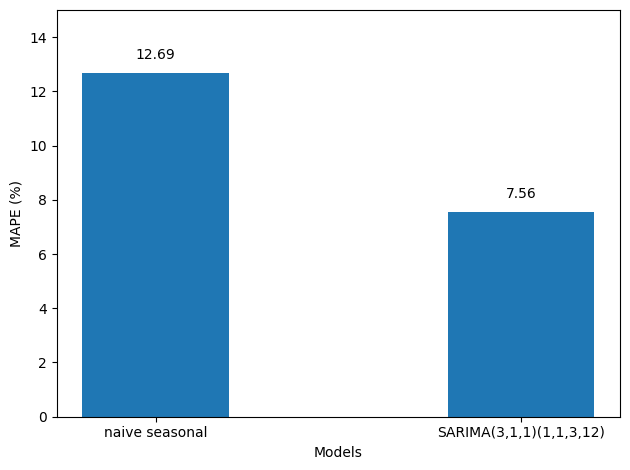

In [35]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'SARIMA(3,1,1)(1,1,3,12)']
y = [mape_naive_seasonal, mape_SARIMA]

ax.bar(x, y, width = 0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x = index, y = value + 0.5, s = str(round(value, 2)), ha = 'center')

plt.tight_layout()

# 질문

만일 d = 0이라면, D = 0인가?
- 계절 성분과는 다른 얘기. 계절 차분(D)가 필요한지는 계절 단위근(seasonal unit root)이 있는지를 봐야하는데, 이건 별도의 검정이 필요.
    - OCSB Test
    - Canova-Hansen Test
    - 또는 실무적으로는 계절적 lag에서 ACF가 천천히 감소하는지, seasonal strength가 강한지를 시각적으로 확인


지금까지는 df안에서 train/test를 떼워놓음. 그러면 이 외의 미래도 모델로 추측이 가능한가?
- 가능함. 그렇게 할 경우, 전체 데이터로 최종 모델을 재학습한 후 n개월 미래 예측.
- 주의점: 
    - 데이터 밖 예측은 미래로 갈수록 불확실성이 커짐 (특히 계절 패턴 반복 가정에 의존)
    - 너무 먼 미래 예측은 신뢰가 떨어짐. 보통 학습 데이터 길이의 일부까지만 실무적으로 의미
    - 재학습 안 하고 test set까지만 학습된 모델로 그 이후 예측해도 되나, 실전에선 가진 데이터 다 쓰고 재학습하는 게 일반적.
